In [1]:
import pandas as pd
import numpy as np
import os

In [123]:
NEW_SET = False

if not NEW_SET:
    dataset_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\DL_NTCP_Multitox\datasets\MT_dataset\stratified_sampling_test_542.csv"
    preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\ensemble_predictions.csv"

    all_features_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\CITOR_REDCAP_clinical_data_important_variables_combined.xlsx"


    df_dataset = pd.read_csv(dataset_dir, sep=';')
    df_preds = pd.read_csv(preds_csv_dir, sep=';')
    df_all_features = pd.read_excel(all_features_dir)

    df_dataset['PatientID'] = df_dataset['PatientID'].astype(str).str.zfill(7)
    df_preds['PatientID'] = df_preds['PatientID'].astype(str).str.zfill(7)
    df_all_features['PatientID'] = df_all_features['UMCG'].astype(str).str.zfill(7)

    # missing values
    df_all_features['Technique'] = df_all_features.apply(
        lambda row: row['Check2'] if row['Technique'] == 0 else row['Technique'], axis=1
    )
    df_all_features["Chemo"] = df_all_features["Modality"].apply(
        lambda x: 1 if isinstance(x, str) and ("Chemo" in x or "Bioradiation" in x) else 0
    )
    df_all_features["Loctum2"].value_counts(dropna=False)


    replace_dict = {'Larynx': 'Larynx', 
                'Oropharynx' : 'Pharynx', 
                'Hypofarynx' : 'Pharynx',
                'Nasopharynx' : 'Pharynx',
                'Neus(bij)holte' : 'Overig',
                'Categorie: overig' : 'Overig',
                }
    df_all_features['Loctum3'] = df_all_features['Loctum2'].replace(replace_dict)
    #df_all_features['Technique'] = df_all_features.apply(df_all_features['Technique'])

    df_merged = pd.merge(df_preds, df_dataset, on='PatientID', how='left')
    df_merged = pd.merge(df_merged, df_all_features[['PatientID', "RTSTART", "Technique", "Chemo", "Loctum3"]], on='PatientID', how='left')

    df_merged['RTSTART_year'] = pd.to_datetime(df_merged['RTSTART']).dt.year

    


In [131]:
from sklearn.metrics import roc_auc_score

def compute_auc(df, endpoint):
    """
    Computes the AUC (Area Under the Curve) for the given predictions and labels.
    Rows with -1 in the labels column are ignored.

    Args:
        predictions (pd.Series): The predictions column.
        labels (pd.Series): The labels column.

    Returns:
        float: The computed AUC score.
    """
    predictions = df[f'{endpoint}_pred']
    labels = df[f'{endpoint}_true']
    # Filter out rows where labels are -1
    valid_indices = labels != -1
    filtered_predictions = predictions[valid_indices]
    filtered_labels = labels[valid_indices]

    # Compute and return AUC
    auc = roc_auc_score(filtered_labels, filtered_predictions)

    return round(auc, 2)

In [132]:
compute_auc(df_merged, 'Xerostomia_M06')

0.8

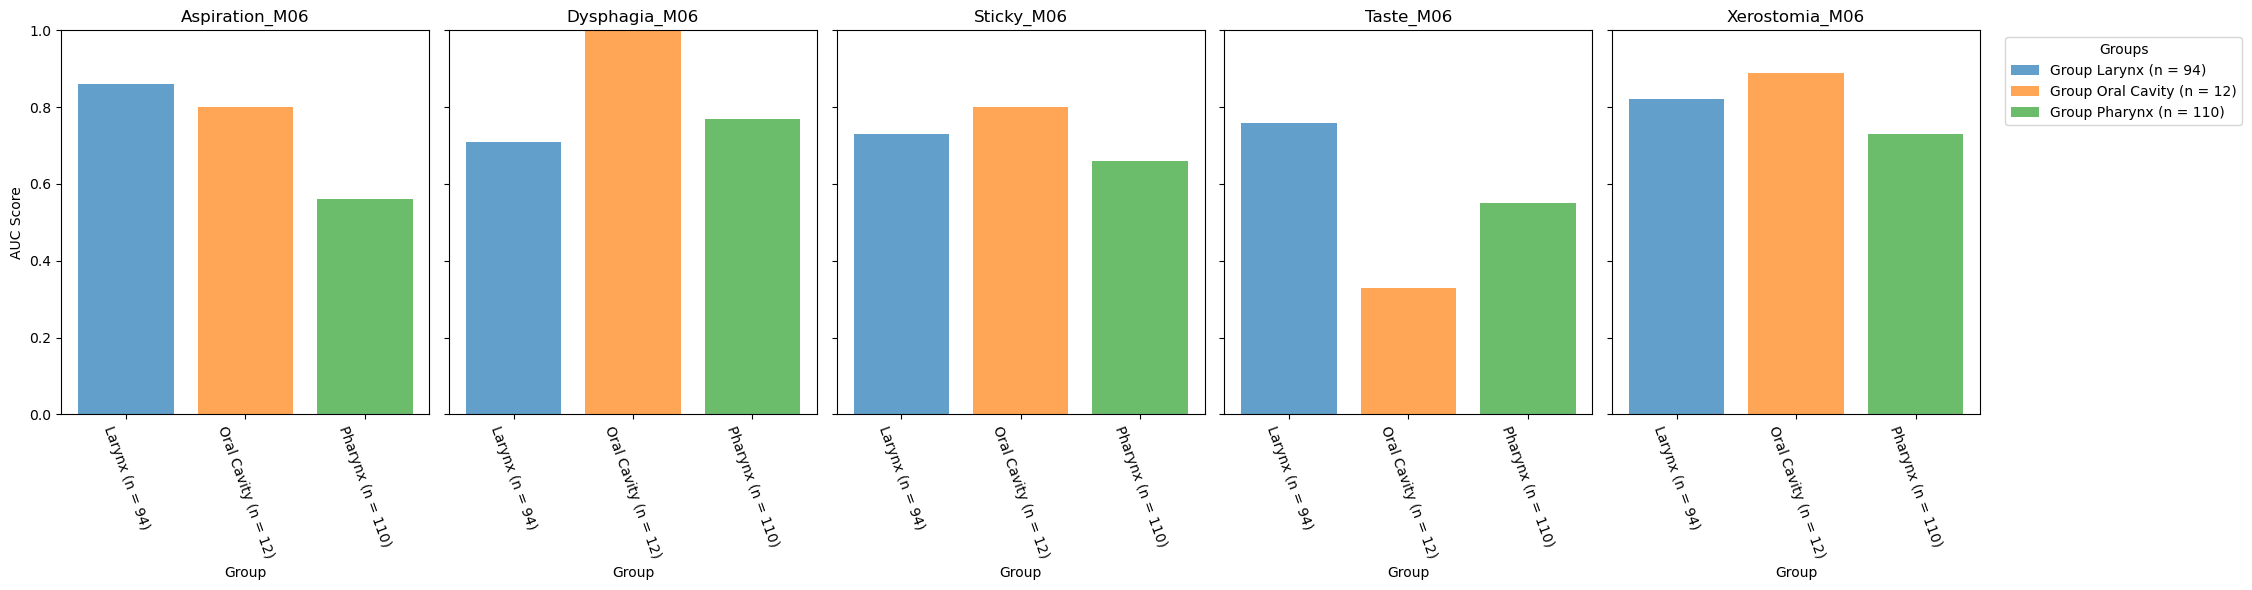

In [133]:
endpoint_columns = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06"]

#endpoint_columns = ["Dysphagia_M06", 'Xerostomia_M06']
def compute_grouped_aucs(df, endpoint_columns, group_column):
    """
    Computes the AUCs for the given endpoints grouped by a categorical column.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        endpoint_columns (list): List of endpoint columns to compute AUCs for.
        group_column (str): The column to group by.

    Returns:
        dict: A dictionary where keys are group values and values are dictionaries of AUC scores for each endpoint.
    """
    grouped_aucs = {}
    for group_value, group_df in df.groupby(group_column):
        group_aucs = {endpoint: compute_auc(group_df, endpoint) for endpoint in endpoint_columns}

        key_name = f"{group_value} (n = {len(group_df)})"
        #key_name = str(group_value)
        grouped_aucs[key_name] = group_aucs
    return grouped_aucs



def compute_grouped_aucs_by_year_range(df, endpoint_columns, start_year, end_year, group_size=2):
    """
    Computes the AUCs for the given endpoints grouped by year ranges.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        endpoint_columns (list): List of endpoint columns to compute AUCs for.
        start_year (int): The starting year of the range.
        end_year (int): The ending year of the range.
        group_size (int): The size of the year range for grouping.

    Returns:
        dict: A dictionary where keys are year ranges and values are dictionaries of AUC scores for each endpoint.
    """
    grouped_aucs = {}
    for year in range(start_year, end_year + 1, group_size):
        year_range = f"{year}-{min(year + group_size - 1, end_year)}"
        group_df = df[(df['RTSTART_year'] >= year) & (df['RTSTART_year'] <= year + group_size - 1)]
        if not group_df.empty:
            group_aucs = {endpoint: compute_auc(group_df, endpoint) for endpoint in endpoint_columns}
            key_name = f"{year_range} (n = {len(group_df)})"
            grouped_aucs[key_name] = round(group_aucs, 2)
    return grouped_aucs

grouped_auc_scores = compute_grouped_aucs(df_merged, endpoint_columns, 'Loctum3')

#grouped_auc_scores = compute_grouped_aucs_by_year_range(df_merged, endpoint_columns, 2008, 2025, group_size=2)
grouped_auc_scores


import matplotlib.pyplot as plt

def plot_grouped_aucs(grouped_auc_scores):
    """
    Plots the AUC scores for each endpoint grouped by a categorical column.

    Args:
        grouped_auc_scores (dict): A dictionary where keys are group values and values are dictionaries of AUC scores for each endpoint.
    """
    fig, axes = plt.subplots(1, len(endpoint_columns), figsize=(20, 6), sharey=True)
    for i, endpoint in enumerate(endpoint_columns):
        for group, auc_scores in grouped_auc_scores.items():
            axes[i].bar(group, auc_scores[endpoint], label=f'Group {group}', alpha=0.7)
        axes[i].set_title(endpoint)
        axes[i].set_ylim(0, 1)
        axes[i].set_xlabel('Group')
        if i == 0:
            axes[i].set_ylabel('AUC Score')
        axes[i].tick_params(axis='x', rotation=-70)

    plt.tight_layout()
    plt.legend(title='Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.show()

plot_grouped_aucs(grouped_auc_scores)

In [134]:
grouped_auc_scores

{'Larynx (n = 94)': {'Aspiration_M06': 0.86,
  'Dysphagia_M06': 0.71,
  'Sticky_M06': 0.73,
  'Taste_M06': 0.76,
  'Xerostomia_M06': 0.82},
 'Oral Cavity (n = 12)': {'Aspiration_M06': 0.8,
  'Dysphagia_M06': 1.0,
  'Sticky_M06': 0.8,
  'Taste_M06': 0.33,
  'Xerostomia_M06': 0.89},
 'Pharynx (n = 110)': {'Aspiration_M06': 0.56,
  'Dysphagia_M06': 0.77,
  'Sticky_M06': 0.66,
  'Taste_M06': 0.55,
  'Xerostomia_M06': 0.73}}

In [96]:
list(df_merged.columns)

['PatientID',
 'Mode',
 'Aspiration_M06_pred',
 'Aspiration_M06_true',
 'Dysphagia_M06_pred',
 'Dysphagia_M06_true',
 'Sticky_M06_pred',
 'Sticky_M06_true',
 'Taste_M06_pred',
 'Taste_M06_true',
 'Xerostomia_M06_pred',
 'Xerostomia_M06_true',
 'Sex',
 'Age',
 'CT+C_available',
 'CT_Artefact',
 'Loctum2',
 'Photons',
 'T_stage',
 'N_stage',
 'Smoking',
 'P16',
 'WHO',
 'Xerostomia_BSL',
 'Xerostomia_W01',
 'Aspiration_BSL',
 'Aspiration_W01',
 'Sticky_BSL',
 'Sticky_W01',
 'Taste_BSL',
 'Taste_W01',
 'Dysphagia_BSL',
 'Dysphagia_W01',
 'Xerostomia_M06',
 'Xerostomia_M12',
 'Xerostomia_M18',
 'Aspiration_M06',
 'Aspiration_M12',
 'Aspiration_M18',
 'Sticky_M06',
 'Sticky_M12',
 'Sticky_M18',
 'Taste_M06',
 'Taste_M12',
 'Taste_M18',
 'Dysphagia_M06',
 'Dysphagia_M12',
 'Dysphagia_M18',
 'Parotid_L_meandose',
 'Parotid_R_meandose',
 'Parotid_meandose',
 'Submandibular_L_meandose',
 'Submandibular_R_meandose',
 'Submandibular_meandose',
 'PCM_Sup_meandose',
 'PCM_Med_meandose',
 'PCM_Inf_m

In [11]:
df_preds

,PatientID,Mode,Aspiration_M06_pred,Aspiration_M06_true,Dysphagia_M06_pred,Dysphagia_M06_true,Sticky_M06_pred,Sticky_M06_true,Taste_M06_pred,Taste_M06_true,Xerostomia_M06_pred,Xerostomia_M06_true
0,0052277,test,0.043978,0.0,0.400356,-1.0,0.289286,0.0,0.263543,1.0,0.452501,0.0
1,0066593,test,0.160205,0.0,0.231431,0.0,0.363443,0.0,0.277286,0.0,0.443394,0.0
2,0092560,test,0.044011,0.0,0.227443,0.0,0.287770,0.0,0.259986,0.0,0.457197,0.0
3,0163517,test,0.027100,0.0,0.033533,0.0,0.109515,0.0,0.052217,0.0,0.092418,0.0
4,0213240,test,0.065761,0.0,0.368783,0.0,0.360731,1.0,0.368292,0.0,0.551680,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
211,9586209,test,0.057228,0.0,0.539665,1.0,0.341252,0.0,0.314760,0.0,0.492753,1.0
212,9597467,test,0.061236,0.0,0.258840,1.0,0.321724,0.0,0.307668,1.0,0.486784,1.0
213,9653665,test,0.099694,0.0,0.254165,0.0,0.355672,1.0,0.338638,1.0,0.493409,1.0
214,9715913,test,0.090030,1.0,0.449579,1.0,0.422078,1.0,0.425273,1.0,0.566986,1.0


# Feature selection